# Service 4 — EV-User Charging and Usage Profiles Prediction

**ENERTEF · TEF EV Node · D2.2 §2.5.4**

This notebook reproduces every calculation behind the Service 4 solution deck. It is the
computational record for the design decisions, the reported metrics, and the figures. The trained
session-energy model, its algorithm bake-off and its Hugging Face card are in
`EV_Session_Energy_Model.ipynb`.

**Data access:** the dataset is restricted and **not redistributed in this repository**. Obtain it
via the data paper below and place it under `Data/` (`JourneyCharge/`, `EnergyStreams/`,
`open_meteo_dingle*.csv`), or set `DINGLE_DATASET_ROOT` to the folder containing them. Install the
dependencies with `pip install -r requirements.txt` and run the notebook from the repository root.

**Data source:** Avgoloupis, D. *et al.* *Residential Energy Dataset with Electric Vehicles,
Photovoltaic Generation and Tariff Variability in Ireland.* Scientific Data (2026) 13:834 —
[doi:10.1038/s41597-026-07186-3](https://doi.org/10.1038/s41597-026-07186-3).
Four "ambassador" households (`id01`–`id04`) from the ESB Networks Dingle Electrification
Project, each with a 2.1 kWp PV array, a 5 kWh sonnenBatterie, a Hyundai Kona Electric
(64 kWh), a Wallbox Pulsar Plus (7.4 kW AC) and an air-source heat pump.

### What is computed here

| § | Section | Produces |
|---|---|---|
| 1 | Setup and path resolution | `DATASET` handles for all four streams |
| 2 | Event-log overview | Per-household session, journey and energy counts |
| 3 | Gap structure and outage taxonomy | The 139 masked household-days; Figure 1 |
| 4 | Temporal patterns | PV / tariff misalignment; Figure 2 |
| 5 | Sessions, windows and profiles | Slack analysis; Figures 3, 7, 8 |
| 6 | Feature engineering | The causal daily panel and SoC reconstruction |
| 7 | Head A — WILL-CHARGE | Feature/model sweep, walk-forward; Figure 5 |
| 8 | Head B — energy volume | nMAE vs. horizon and aggregation, against a trailing-average baseline; Figure 4 |
| 9 | Head C — connection window | Dwell-hour regression |
| 10 | Physical closure | Charged energy vs. driven distance |
| 11 | Counterfactual value | Tariff and PV re-scheduling; Figure 6 |
| 12 | Results summary | Every number quoted in the deck |

### The one idea the whole notebook turns on

Charging **timing** is behavioural and only weakly predictable. Charging **volume** is bounded
by physics — energy charged must eventually equal energy driven — so it becomes predictable as
the horizon and the portfolio widen; the model is not what makes it predictable, a trailing
average of the household's own recent pace does as well (§10.2). The **connection window** is wide
enough (median 9.4 h plug-in against 3.7 h of actual charging) that a scheduler does not need
accurate timing to act. Sections 7–11 test each of those three claims in turn, **each against a
no-model baseline**. Pooled scores flatter when households differ (a household's own base rate
alone gives a pooled AUC of 0.63), so within-household scores are reported too.

## 1 · Setup, imports and path resolution

The dataset is not part of this repository: the loader looks in `DINGLE_DATASET_ROOT` (when set)
and in `Data/`, and reports what it resolved for each stream.

In [1]:
import os
import json
import warnings
from pathlib import Path

# joblib cannot count physical cores on recent Windows (no `wmic`) and prints a traceback when
# LightGBM asks for them; a core count below the logical total makes it skip that probe.
if os.name == "nt":
    os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(max(1, (os.cpu_count() or 2) // 2)))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    f1_score, precision_score, recall_score, mean_absolute_error, roc_curve,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

# ---- physical constants of the pilot fleet (per the Data Descriptor) ----------
CAPACITY_KWH = 64.0      # Hyundai Kona Electric usable pack
CONSUMPTION  = 0.168     # kWh/km, used for SoC reconstruction
CHARGER_KW   = 7.4       # Wallbox Pulsar Plus, single-phase AC
SLOT_H       = 0.5       # 30-minute settlement slot
PV_KWP       = 2.1

IDS = ["id01", "id02", "id03", "id04"]
OUTAGE_GAP_DAYS = 7      # journey-log gap above which we call it a telemetry outage
MIN_TRIP_KM     = 1.0    # below this a "journey" is a manoeuvre or GPS jitter
WARMUP_DAYS     = 28     # lag warm-up before a household-day is trainable
MIN_HISTORY_MONTHS = 6   # months of history before the first walk-forward fold

OUT_DIR = Path("outputs")
FIG_DIR = Path("outputs/figures")
for d in (OUT_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"outputs -> {OUT_DIR.as_posix()}/")
print(f"figures -> {FIG_DIR.as_posix()}/")

outputs -> outputs/
figures -> outputs/figures/


In [2]:
def resolve_dataset() -> dict:
    """Locate the four data streams across a list of candidate roots.

    Returns a dict of {stream: [paths]}. Each stream is searched independently so a
    split layout (energy streams in the repo, mobility logs outside it) still resolves.
    """
    candidates = [
        Path(os.environ["DINGLE_DATASET_ROOT"]) if os.environ.get("DINGLE_DATASET_ROOT") else None,
        Path("Data"),
    ]
    candidates = [c for c in candidates if c is not None and c.exists()]

    found = {"mobility": [], "energy": [], "weather": []}
    patterns = {
        "mobility": "*_Sorted_Mobility.csv",
        "energy":   "id0*_merged_30min*.csv",
        "weather":  "open_meteo_dingle*.csv",
    }
    for stream, pattern in patterns.items():
        for root in candidates:
            hits = sorted(root.rglob(pattern))
            if stream == "energy":
                # prefer the interpolated EnergyStreams copy over RawData
                preferred = [h for h in hits if "RawData" not in h.parts]
                hits = preferred or hits
                # one file per household
                seen, unique = set(), []
                for h in hits:
                    if h.name[:4] not in seen:
                        seen.add(h.name[:4]); unique.append(h)
                hits = unique
            if hits:
                found[stream] = hits
                print(f"{stream:9s} <- {root}  ({len(hits)} files)")
                break
        else:
            print(f"{stream:9s} <- NOT FOUND in any candidate root")
    return found


DATASET = resolve_dataset()
missing = [k for k, v in DATASET.items() if not v]
if missing:
    raise FileNotFoundError(
        f"Missing stream(s): {missing}. Set DINGLE_DATASET_ROOT to the folder containing "
        f"EnergyStreams/, JourneyCharge/ and open_meteo_dingle*.csv"
    )

mobility  <- Data  (4 files)
energy    <- Data  (4 files)
weather   <- Data  (2 files)


### Plot styling

The deck's figures use a validated categorical palette on a light chart surface. Adjacent
hues clear a CVD separation threshold of ΔE ≥ 8 (OKLab ×100), so the figures stay legible
under the common colour-vision deficiencies and in greyscale print.

In [3]:
SURF  = "#fcfcfb"                              # chart surface
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
S1, S2, S3, S4 = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"   # categorical slots 1-4
BLU_200, NEUTRAL, CRIT = "#9ec5f4", "#f0efec", "#d03b3b"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.titlesize": 11, "axes.labelsize": 9.5,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 120,
})


def clean(ax, grid="y"):
    """Hairline chrome: drop the top/right spines, recess the grid."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    if grid:
        ax.grid(axis=grid, lw=0.8, color=GRID, zorder=0)
        ax.set_axisbelow(True)
    return ax


def save_fig(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, bbox_inches="tight", dpi=200)
    print(f"saved {path}")

## 2 · Load the event logs and energy streams

`CHARGING_TIME` is an `HH:MM:SS` string giving **active charging time**, which is not the same
as the wall-clock difference between `start_time` and `end_time`. That difference is the
**dwell** (plug-in) window. The gap between the two is the schedulable slack, and §5 shows it
is the single most important quantity in this dataset.

`Duration` on journey rows is in milliseconds.

In [4]:
def parse_hhmmss(value) -> float:
    """'HH:MM:SS' -> hours. Returns NaN for missing values."""
    if pd.isna(value):
        return np.nan
    h, m, s = str(value).split(":")
    return int(h) + int(m) / 60 + float(s) / 3600


def load_mobility() -> dict:
    """Event logs per household, with dwell and active-charge durations derived."""
    out = {}
    for path in DATASET["mobility"]:
        hid = path.name[:4]
        d = pd.read_csv(path)
        d["start_time"] = pd.to_datetime(d.start_time)
        d["end_time"] = pd.to_datetime(d.end_time)
        d["dwell_h"] = (d.end_time - d.start_time).dt.total_seconds() / 3600
        d["charge_h"] = d.CHARGING_TIME.apply(parse_hhmmss)
        d["journey_min"] = d.Duration / 1000 / 60          # ms -> minutes
        out[hid] = d
    return out


MOBILITY = load_mobility()

ENERGY = {}
for path in DATASET["energy"]:
    e = pd.read_csv(path)
    e["timestamp"] = pd.to_datetime(e.timestamp, utc=True)
    e["ts_naive"] = e.timestamp.dt.tz_localize(None)
    ENERGY[path.name[:4]] = e

# Weather: dingle2 matched id01/id02 best, dingle1 matched id03/id04 (Data Descriptor §Technical Validation)
WEATHER = {}
for path in DATASET["weather"]:
    w = pd.read_csv(path)
    w["date"] = pd.to_datetime(w.date)
    WEATHER[path.stem] = w

WEATHER_FOR = {"id01": "open_meteo_dingle2", "id02": "open_meteo_dingle2",
               "id03": "open_meteo_dingle1", "id04": "open_meteo_dingle1"}

print("mobility rows:", {k: len(v) for k, v in MOBILITY.items()})
print("energy rows:  ", {k: len(v) for k, v in ENERGY.items()})

mobility rows: {'id01': 2558, 'id02': 3929, 'id03': 6379, 'id04': 6475}
energy rows:   {'id01': 52945, 'id02': 54095, 'id03': 52129, 'id04': 53569}


## 3 · Event-log overview

In [5]:
rows = []
for hid, d in MOBILITY.items():
    journeys = d[d.event_type == "journey"]
    charges = d[d.event_type == "charging"]
    span = (d.start_time.max() - d.start_time.min()).days + 1
    rows.append({
        "id": hid,
        "span_days": span,
        "journeys": len(journeys),
        "charging_sessions": len(charges),
        "km_total": round(journeys.Distance.sum()),
        "kWh_total": round(charges.ENERGY.sum()),
        "kWh_median": round(charges.ENERGY.median(), 2),
        "dwell_h_median": round(charges.dwell_h.median(), 2),
        "charge_h_median": round(charges.charge_h.median(), 2),
        "days_between_charges": round(span / len(charges), 2),
    })

overview = pd.DataFrame(rows)
display(overview)

ALL_CHARGE = pd.concat([d[d.event_type == "charging"] for d in MOBILITY.values()], ignore_index=True)
ALL_JOURNEY = pd.concat([d[d.event_type == "journey"] for d in MOBILITY.values()], ignore_index=True)
ALL_CHARGE["slack_h"] = ALL_CHARGE.dwell_h - ALL_CHARGE.charge_h
ALL_CHARGE["hour"] = ALL_CHARGE.start_time.dt.hour
ALL_JOURNEY["hour"] = ALL_JOURNEY.start_time.dt.hour

print(f"\nPOOLED  {len(ALL_CHARGE)} charging sessions, {len(ALL_JOURNEY)} journeys")
print(f"  energy delivered   {ALL_CHARGE.ENERGY.sum():,.0f} kWh   "
      f"median {ALL_CHARGE.ENERGY.median():.1f}  mean {ALL_CHARGE.ENERGY.mean():.1f}")
print(f"  distance driven    {ALL_JOURNEY.Distance.sum():,.0f} km")
print(f"  sub-{MIN_TRIP_KM:.0f} km journeys  {100 * (ALL_JOURNEY.Distance < MIN_TRIP_KM).mean():.0f}% of all logged journeys")

,id,span_days,journeys,charging_sessions,km_total,kWh_total,kWh_median,dwell_h_median,charge_h_median,days_between_charges
0,id01,364,2405,153,15000,2935,10.85,8.69,2.48,2.38
1,id02,365,3634,295,31297,8302,23.51,8.42,3.78,1.24
2,id03,364,6290,89,17844,2697,29.22,9.64,4.15,4.09
3,id04,364,6274,201,28842,5692,28.93,10.90,4.30,1.81



POOLED  738 charging sessions, 18603 journeys
  energy delivered   19,626 kWh   median 23.9  mean 26.6
  distance driven    92,983 km
  sub-1 km journeys  53% of all logged journeys


Two facts already visible in that table shape the whole service:

- **Charging is rare relative to driving.** A household charges every 1.2–4.1 days, so a
  day-level target is heavily imbalanced and event-sparse.
- **Dwell far exceeds active charging** in every household. That gap is the flexibility.

## 4 · Gap structure and the outage taxonomy

Three different things produce an empty row, and conflating them is the largest avoidable
error in this service:

1. **A genuine quiet day** — the car was driven but not charged, or not used. A true negative.
2. **A telemetry outage** — the logger stopped. Journeys *and* charging vanish together. This
   is not evidence of no charging, and must never enter training as a negative.
3. **A sub-threshold record** — a "journey" under 1 km, i.e. a parking manoeuvre or GPS jitter.

An outage is detected as a gap in the **journey** log longer than `OUTAGE_GAP_DAYS`. Journeys
are the right detector because they are frequent (people drive most days) whereas charging is
legitimately sparse — a two-week charging gap can be real behaviour, a two-week journey gap
cannot.

In [6]:
def outage_mask(journeys: pd.DataFrame, index: pd.DatetimeIndex,
                threshold_days: int = OUTAGE_GAP_DAYS) -> pd.Series:
    """True for days that fall strictly inside a journey-log gap > threshold_days."""
    mask = pd.Series(False, index=index)
    starts = journeys.start_time.sort_values().reset_index(drop=True)
    gaps = starts.diff().dt.total_seconds() / 86400
    for k in np.where(gaps > threshold_days)[0]:
        mask.loc[(index > starts[k - 1]) & (index < starts[k])] = True
    return mask


gap_rows, outage_rows = [], []
for hid, d in MOBILITY.items():
    journeys = d[d.event_type == "journey"].sort_values("start_time")
    charges = d[d.event_type == "charging"].sort_values("start_time")
    calendar = pd.date_range(d.start_time.min().normalize(), d.start_time.max().normalize(), freq="D")

    charge_days = set(charges.start_time.dt.normalize())
    journey_days = set(journeys.start_time.dt.normalize())
    charge_gaps = charges.start_time.diff().dt.total_seconds() / 86400

    gap_rows.append({
        "id": hid,
        "calendar_days": len(calendar),
        "days_with_charge": len(charge_days),
        "pct_days_charge": round(100 * len(charge_days) / len(calendar), 1),
        "pct_days_journey": round(100 * len(journey_days) / len(calendar), 1),
        "median_gap_d": round(charge_gaps.median(), 2),
        "p90_gap_d": round(charge_gaps.quantile(0.9), 1),
        "max_gap_d": round(charge_gaps.max(), 1),
    })

    jgaps = journeys.start_time.diff().dt.total_seconds() / 86400
    big = jgaps[jgaps > OUTAGE_GAP_DAYS]
    outage_rows.append({
        "id": hid,
        "outage_windows": len(big),
        "outage_days": round(big.sum(), 1),
        "pct_of_span_lost": round(100 * big.sum() / len(calendar), 1),
        "longest_window_d": round(big.max(), 1) if len(big) else 0.0,
    })

print("Charging sparsity — how often does a household actually charge?")
display(pd.DataFrame(gap_rows))
print("Telemetry outages — journey-log gaps > 7 days (NOT behaviour)")
display(pd.DataFrame(outage_rows))

Charging sparsity — how often does a household actually charge?


,id,calendar_days,days_with_charge,pct_days_charge,pct_days_journey,median_gap_d,p90_gap_d,max_gap_d
0,id01,365,112,30.7,72.9,1.01,6.1,25.6
1,id02,365,194,53.2,86.0,0.81,2.9,10.6
2,id03,365,79,21.6,98.9,3.00,7.3,23.0
3,id04,364,175,48.1,91.5,1.66,3.7,6.0


Telemetry outages — journey-log gaps > 7 days (NOT behaviour)


,id,outage_windows,outage_days,pct_of_span_lost,longest_window_d
0,id01,1,81.7,22.4,81.7
1,id02,2,42.9,11.8,34.1
2,id03,0,0.0,0.0,0.0
3,id04,1,14.1,3.9,14.1


`id01` loses 81.7 consecutive days — 22% of its record — to a single outage, while `id03` has
none at all. A pipeline that reads those 81.7 days as "did not charge" would learn that long
silences predict no charging, and would learn it from the periods it weights most heavily.

### Figure 1 · Event-log availability per household

saved outputs\figures\f1_gaps.png


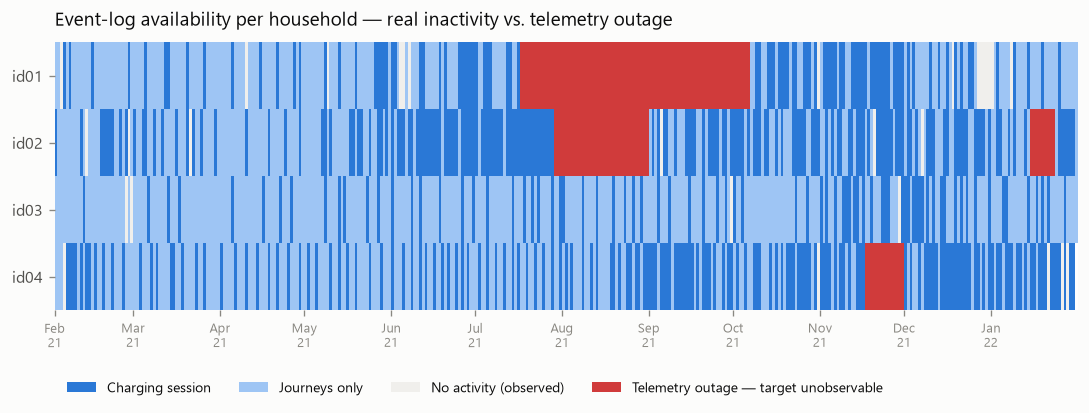

In [7]:
fig, ax = plt.subplots(figsize=(11, 2.9))

all_dates = pd.date_range(
    min(d.start_time.min() for d in MOBILITY.values()).normalize(),
    max(d.start_time.max() for d in MOBILITY.values()).normalize(), freq="D")

matrix = []
for hid in IDS:                                    # row 0 = id01, drawn at the top
    d = MOBILITY[hid]
    journeys = d[d.event_type == "journey"]
    charges = d[d.event_type == "charging"]
    idx = pd.date_range(d.start_time.min().normalize(), d.start_time.max().normalize(), freq="D")

    state = pd.Series(4.0, index=all_dates)        # 4 = outside this household's record
    state.loc[idx] = 0.0                           # 0 = observed, no activity
    jd = journeys.groupby(journeys.start_time.dt.normalize()).size()
    cd = charges.groupby(charges.start_time.dt.normalize()).size()
    state.loc[jd.index] = 1.0                      # 1 = journeys only
    state.loc[cd.index] = 2.0                      # 2 = charging session
    om = outage_mask(journeys, idx)
    state.loc[om[om].index] = 3.0                  # 3 = telemetry outage
    matrix.append(state.values)

cmap = ListedColormap([NEUTRAL, BLU_200, S1, CRIT, "#ffffff"])
ax.imshow(np.array(matrix), aspect="auto", cmap=cmap, vmin=0, vmax=4,
          interpolation="nearest", extent=[0, len(all_dates), 0, 4])
ax.set_yticks(np.arange(4) + 0.5)
ax.set_yticklabels(IDS[::-1], fontsize=9.5, color=INK2)
ticks = [i for i, t in enumerate(all_dates) if t.day == 1]
ax.set_xticks(ticks)
ax.set_xticklabels([all_dates[i].strftime("%b\n%y") for i in ticks], fontsize=8)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Event-log availability per household — real inactivity vs. telemetry outage",
             loc="left", color=INK, fontsize=11.5, pad=10)
ax.legend(handles=[
    mpatches.Patch(fc=S1, label="Charging session"),
    mpatches.Patch(fc=BLU_200, label="Journeys only"),
    mpatches.Patch(fc=NEUTRAL, label="No activity (observed)"),
    mpatches.Patch(fc=CRIT, label="Telemetry outage — target unobservable"),
], ncol=4, loc="upper left", bbox_to_anchor=(0, -0.22), fontsize=8.5)

save_fig(fig, "f1_gaps.png")
plt.show()

## 5 · Temporal patterns — the misalignment that creates the opportunity

Charging start times are compared against journey starts, mean PV yield and the SUSTAIN tariff.
These are four different quantities on four different scales, so they are drawn as small
multiples sharing one x-axis rather than on twinned y-axes.

In [8]:
hour_charge = ALL_CHARGE.hour.value_counts().reindex(range(24), fill_value=0)
hour_journey = ALL_JOURNEY.hour.value_counts().reindex(range(24), fill_value=0)

energy_all = pd.concat(ENERGY.values(), ignore_index=True)
pv_by_hour = energy_all.groupby(energy_all.ts_naive.dt.hour).solar_kWh.mean()
price_by_hour = energy_all.groupby(energy_all.ts_naive.dt.hour).elec_price.mean()

evening_share = 100 * ALL_CHARGE.hour.between(18, 23).mean()
pv_window_share = 100 * ALL_CHARGE.hour.between(10, 16).mean()

print(f"charging starts 18:00-24:00 : {evening_share:.0f}%")
print(f"charging starts 10:00-16:00 : {pv_window_share:.0f}%  (the PV window)")
print(f"tariff  00:00-07:00 mean    : {price_by_hour.loc[0:6].mean():.3f} EUR/kWh")
print(f"tariff  08:00-23:00 mean    : {price_by_hour.loc[8:23].mean():.3f} EUR/kWh")
print(f"day/night spread            : {price_by_hour.loc[8:23].mean() / price_by_hour.loc[0:6].mean():.1f}x")

charging starts 18:00-24:00 : 53%
charging starts 10:00-16:00 : 23%  (the PV window)
tariff  00:00-07:00 mean    : 0.035 EUR/kWh
tariff  08:00-23:00 mean    : 0.095 EUR/kWh
day/night spread            : 2.7x


### Figure 2 · Hour-of-day small multiples

saved outputs\figures\f2_hourly.png


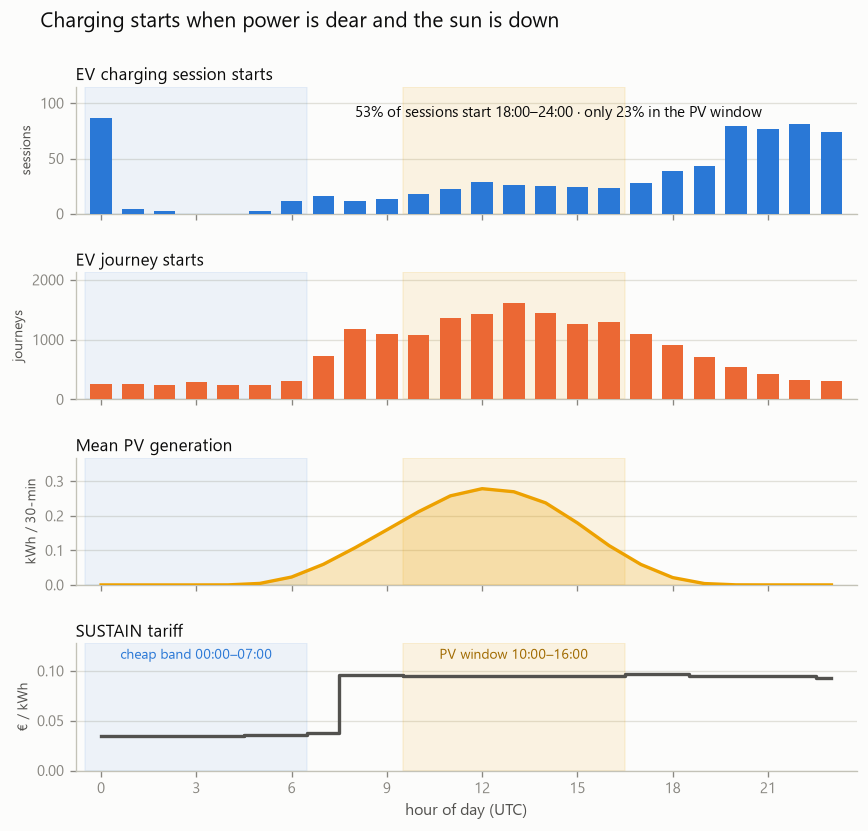

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(8.4, 7.4), sharex=True, gridspec_kw=dict(hspace=0.46))
hours = np.arange(24)
panels = [
    (hour_charge.values,   S1,   "EV charging session starts", "sessions",    "bar"),
    (hour_journey.values,  S2,   "EV journey starts",          "journeys",    "bar"),
    (pv_by_hour.values,    S4,   "Mean PV generation",         "kWh / 30-min", "line"),
    (price_by_hour.values, INK2, "SUSTAIN tariff",             "€ / kWh",     "step"),
]
for ax, (values, colour, title, ylabel, kind) in zip(axes, panels):
    values = np.asarray(values, dtype=float)
    ax.axvspan(-0.5, 6.5, color=S1, alpha=0.07, zorder=1)     # cheap tariff band
    ax.axvspan(9.5, 16.5, color=S4, alpha=0.10, zorder=1)     # PV window
    if kind == "bar":
        ax.bar(hours, values, color=colour, width=0.68, zorder=3)
    elif kind == "line":
        ax.fill_between(hours, values, color=colour, alpha=0.25, zorder=2)
        ax.plot(hours, values, color=colour, lw=2, zorder=3)
    else:
        ax.step(hours, values, color=colour, lw=2, where="mid", zorder=3)
    clean(ax)
    ax.set_title(title, loc="left", fontsize=10, color=INK, pad=4)
    ax.set_ylabel(ylabel, fontsize=8.5)
    ax.set_ylim(0, values.max() * 1.32)

axes[0].text(8.0, hour_charge.max() * 1.12,
             f"{evening_share:.0f}% of sessions start 18:00–24:00 · "
             f"only {pv_window_share:.0f}% in the PV window",
             fontsize=9, color=INK, ha="left", va="top")
axes[3].text(3.0, price_by_hour.max() * 1.16, "cheap band 00:00–07:00",
             fontsize=8.5, color=S1, ha="center")
axes[3].text(13.0, price_by_hour.max() * 1.16, "PV window 10:00–16:00",
             fontsize=8.5, color="#a06a00", ha="center")
axes[-1].set_xticks(range(0, 24, 3))
axes[-1].set_xlim(-0.8, 23.8)
axes[-1].set_xlabel("hour of day (UTC)", fontsize=9.5)
fig.suptitle("Charging starts when power is dear and the sun is down",
             x=0.09, y=0.965, ha="left", fontsize=12.5, color=INK)

save_fig(fig, "f2_hourly.png")
plt.show()

## 6 · Sessions, connection windows and behavioural profiles

### The connection window is the flexibility

The distinction between `dwell_h` (how long the car is plugged in) and `charge_h` (how long it
actually draws power) is what makes charging shiftable without the user noticing.

In [10]:
overnight = ALL_CHARGE[(ALL_CHARGE.hour >= 17) | (ALL_CHARGE.hour <= 2)]

print(f"dwell            median {ALL_CHARGE.dwell_h.median():.2f} h   p90 {ALL_CHARGE.dwell_h.quantile(.9):.1f} h")
print(f"active charging  median {ALL_CHARGE.charge_h.median():.2f} h   p90 {ALL_CHARGE.charge_h.quantile(.9):.1f} h")
print(f"slack            median {ALL_CHARGE.slack_h.median():.2f} h   mean {ALL_CHARGE.slack_h.mean():.2f} h")
print(f"  sessions with > 2 h slack : {100 * (ALL_CHARGE.slack_h > 2).mean():.0f}%")
print(f"\novernight sessions (plug-in 17:00-02:00): {len(overnight)} of {len(ALL_CHARGE)} "
      f"({100 * len(overnight) / len(ALL_CHARGE):.0f}%)")
print(f"  median dwell {overnight.dwell_h.median():.1f} h — the whole 7 h cheap band fits inside")
print(f"  they carry {100 * overnight.ENERGY.sum() / ALL_CHARGE.ENERGY.sum():.0f}% of all charged energy")

dwell            median 9.37 h   p90 14.0 h
active charging  median 3.71 h   p90 8.0 h
slack            median 3.54 h   mean 4.37 h
  sessions with > 2 h slack : 60%

overnight sessions (plug-in 17:00-02:00): 515 of 738 (70%)
  median dwell 10.5 h — the whole 7 h cheap band fits inside
  they carry 87% of all charged energy


### Figure 3 · Connection window vs. energy delivery

saved outputs\figures\f3_slack.png


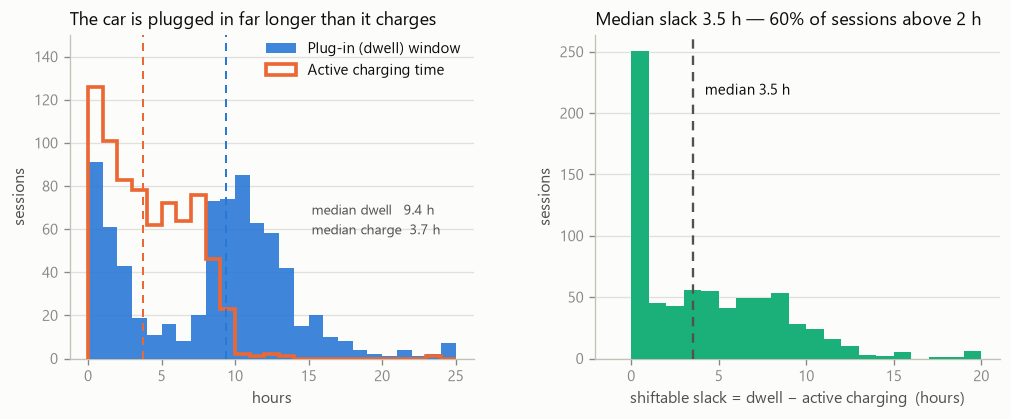

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), gridspec_kw=dict(wspace=0.3))

ax = axes[0]
bins = np.arange(0, 26, 1)
ax.hist(ALL_CHARGE.dwell_h.clip(0, 25), bins=bins, color=S1, alpha=0.9,
        label="Plug-in (dwell) window", zorder=3)
ax.hist(ALL_CHARGE.charge_h.clip(0, 25), bins=bins, histtype="step", color=S2, lw=2.2,
        label="Active charging time", zorder=4)
clean(ax)
ax.axvline(ALL_CHARGE.dwell_h.median(), color=S1, lw=1.2, ls=(0, (4, 3)), zorder=5)
ax.axvline(ALL_CHARGE.charge_h.median(), color=S2, lw=1.2, ls=(0, (4, 3)), zorder=5)
ax.text(15.2, 74, f"median dwell   {ALL_CHARGE.dwell_h.median():.1f} h\n"
                  f"median charge  {ALL_CHARGE.charge_h.median():.1f} h",
        fontsize=8.5, color=INK2, va="top", linespacing=1.6)
ax.set_xlabel("hours"); ax.set_ylabel("sessions"); ax.set_ylim(0, 150)
ax.set_title("The car is plugged in far longer than it charges", loc="left",
             fontsize=10.5, color=INK)
ax.legend(loc="upper right", bbox_to_anchor=(1.0, 1.02))

ax = axes[1]
ax.hist(ALL_CHARGE.slack_h.dropna().clip(-1, 20), bins=np.arange(-1, 21, 1), color=S3, zorder=3)
clean(ax)
ax.axvline(ALL_CHARGE.slack_h.median(), color=INK2, lw=1.4, ls=(0, (4, 3)), zorder=5)
ax.annotate(f"median {ALL_CHARGE.slack_h.median():.1f} h",
            xy=(ALL_CHARGE.slack_h.median(), 215), xytext=(7, 0),
            textcoords="offset points", fontsize=9, color=INK)
ax.set_xlabel("shiftable slack = dwell − active charging  (hours)")
ax.set_ylabel("sessions")
ax.set_title(f"Median slack {ALL_CHARGE.slack_h.median():.1f} h — "
             f"{100 * (ALL_CHARGE.slack_h > 2).mean():.0f}% of sessions above 2 h",
             loc="left", fontsize=10.5, color=INK)

save_fig(fig, "f3_slack.png")
plt.show()

### Figure 8 · Session energy is bimodal

saved outputs\figures\f8_energy.png


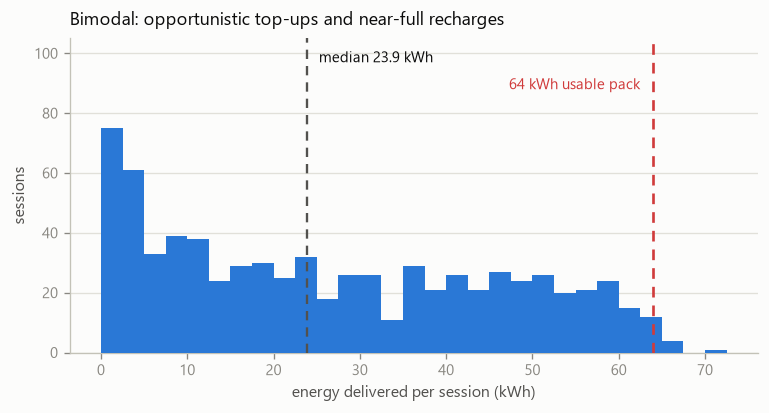

In [12]:
fig, ax = plt.subplots(figsize=(7.4, 3.4))
ax.hist(ALL_CHARGE.ENERGY.dropna(), bins=np.arange(0, 75, 2.5), color=S1, zorder=3)
clean(ax)
ax.axvline(CAPACITY_KWH, color=CRIT, lw=1.6, ls=(0, (4, 3)), zorder=5)
ax.annotate(f"{CAPACITY_KWH:.0f} kWh usable pack", xy=(CAPACITY_KWH, 88), xytext=(-8, 0),
            textcoords="offset points", ha="right", fontsize=9, color=CRIT)
ax.axvline(ALL_CHARGE.ENERGY.median(), color=INK2, lw=1.4, ls=(0, (4, 3)), zorder=5)
ax.annotate(f"median {ALL_CHARGE.ENERGY.median():.1f} kWh",
            xy=(ALL_CHARGE.ENERGY.median(), 97), xytext=(7, 0),
            textcoords="offset points", fontsize=9, color=INK)
ax.set_xlabel("energy delivered per session (kWh)"); ax.set_ylabel("sessions")
ax.set_ylim(0, 105)
ax.set_title("Bimodal: opportunistic top-ups and near-full recharges",
             loc="left", fontsize=10.5, color=INK, pad=8)

save_fig(fig, "f8_energy.png")
plt.show()

The distribution has a dense cluster of small top-ups and a second mode near the pack
capacity. A single central estimate serves neither mode, which is why Head B is trained as a
conditional regressor rather than as a mean predictor.

### Behavioural segmentation

D2.2 asks for user segmentation. With four households the segments are assigned by rule rather
than clustered — four points cannot support an unsupervised partition, and pretending otherwise
would be a false claim of rigour.

In [13]:
profile_rows = []
for hid, d in MOBILITY.items():
    journeys = d[d.event_type == "journey"]
    charges = d[d.event_type == "charging"]
    calendar = pd.date_range(d.start_time.min().normalize(), d.start_time.max().normalize(), freq="D")
    om = outage_mask(journeys, calendar)
    observed_days = (~om).sum()
    charge_days = len(set(charges.start_time.dt.normalize()) - set(calendar[om]))

    profile_rows.append({
        "id": hid,
        "charge_freq_pct": round(100 * charge_days / observed_days, 1),
        "kwh_per_session": round(charges.ENERGY.mean(), 1),
        "dwell_median_h": round(charges.dwell_h.median(), 1),
        "evening_pct": round(100 * charges.start_time.dt.hour.between(18, 23).mean()),
        "weekend_pct": round(100 * (charges.start_time.dt.dayofweek >= 5).mean()),
    })

profiles = pd.DataFrame(profile_rows)


def segment(row):
    if row.charge_freq_pct > 45 and row.kwh_per_session < 30:
        return "Frequent / top-up charger"
    if row.charge_freq_pct < 25:
        return "Opportunistic / deep-cycle charger"
    return "Commuter / routine charger"


profiles["segment"] = profiles.apply(segment, axis=1)
display(profiles)

,id,charge_freq_pct,kwh_per_session,dwell_median_h,evening_pct,weekend_pct,segment
0,id01,33.2,19.2,8.7,28,29,Commuter / routine charger
1,id02,52.8,28.1,8.4,52,24,Frequent / top-up charger
2,id03,21.6,30.3,9.6,67,27,Opportunistic / deep-cycle charger
3,id04,47.1,28.3,10.9,68,28,Frequent / top-up charger


### Figure 7 · Behavioural regimes

saved outputs\figures\f7_profiles.png


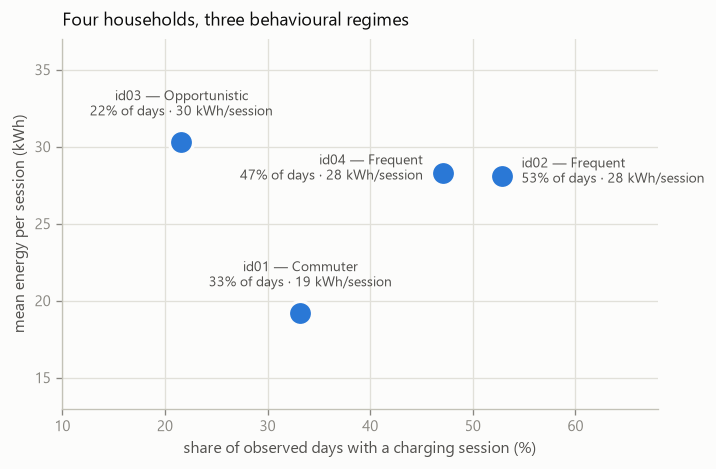

In [14]:
fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.scatter(profiles.charge_freq_pct, profiles.kwh_per_session, s=210, color=S1,
           zorder=4, edgecolor=SURF, linewidth=2)
offsets = {"id01": (0, 16, "center"), "id02": (12, -4, "left"),
           "id03": (0, 16, "center"), "id04": (-12, -4, "right")}
for _, r in profiles.iterrows():
    dx, dy, ha = offsets[r.id]
    ax.annotate(f"{r.id} — {r.segment.split('/')[0].strip()}\n"
                f"{r.charge_freq_pct:.0f}% of days · {r.kwh_per_session:.0f} kWh/session",
                xy=(r.charge_freq_pct, r.kwh_per_session), xytext=(dx, dy),
                textcoords="offset points", ha=ha, fontsize=8.5, color=INK2)
clean(ax, grid="both")
ax.set_xlabel("share of observed days with a charging session (%)")
ax.set_ylabel("mean energy per session (kWh)")
ax.set_xlim(10, 68); ax.set_ylim(13, 37)
ax.set_title("Four households, three behavioural regimes", loc="left",
             fontsize=11, color=INK, pad=8)

save_fig(fig, "f7_profiles.png")
plt.show()

## 7 · Feature engineering — the causal daily panel

Every feature is computed from information available **strictly before** the forecast issue
time. The three rules enforced below:

1. **Lag everything.** Rolling aggregates are `.shift(1)` before `.rolling()`, so day *t* never
   sees day *t*'s own outcome.
2. **Expand, never average globally.** Per-user and per-weekday base rates use
   `.expanding()` on lagged values, so early folds do not borrow late-period statistics.
3. **Mask, never impute, the outages.** Outage days are dropped from the panel entirely rather
   than filled with zeros.

**State-of-charge reconstruction** follows the Data Descriptor: the vehicle reports no
continuous battery level, so SoC is propagated forward as
`SoC(t) = clip(SoC(t-1) − km(t)·0.168 + kWh_charged(t), 0, 64)`. It is a proxy, not a
measurement — its value is as a *relative* recency/need signal, and §7 shows it is the feature
family that carries the classifier.

In [15]:
def build_panel(hid: str) -> pd.DataFrame:
    """One row per household-day, with strictly causal features."""
    d = MOBILITY[hid]
    journeys = d[d.event_type == "journey"]
    charges = d[d.event_type == "charging"].sort_values("start_time")
    idx = pd.date_range(d.start_time.min().normalize(), d.start_time.max().normalize(), freq="D")

    # Only real trips feed the mobility features; 53% of rows are sub-km manoeuvres.
    real_trips = journeys[journeys.Distance > MIN_TRIP_KM]
    km = real_trips.groupby(real_trips.start_time.dt.normalize()).Distance.sum().reindex(idx, fill_value=0.0)
    n_trips = real_trips.groupby(real_trips.start_time.dt.normalize()).size().reindex(idx, fill_value=0)
    kwh = charges.groupby(charges.start_time.dt.normalize()).ENERGY.sum().reindex(idx, fill_value=0.0)

    p = pd.DataFrame({
        "id": hid, "date": idx,
        "km": km.values, "n_trips": n_trips.values, "kwh": kwh.values,
        "y": (kwh.values > 0).astype(int),
    })
    p["outage"] = outage_mask(journeys, idx).values

    # ---- state-of-charge reconstruction (forward propagation) -----------------
    soc = np.zeros(len(p))
    level = CAPACITY_KWH * 0.7                      # neutral start; washes out within a week
    for k in range(len(p)):
        level = min(CAPACITY_KWH, max(0.0, level - p.km.iat[k] * CONSUMPTION + p.kwh.iat[k]))
        soc[k] = level
    p["soc_prev"] = np.r_[CAPACITY_KWH * 0.7, soc[:-1]]     # lagged: known at issue time

    # ---- calendar -------------------------------------------------------------
    p["dow"] = p.date.dt.dayofweek
    p["month"] = p.date.dt.month
    p["is_we"] = (p.dow >= 5).astype(int)

    # ---- lagged rolling aggregates -------------------------------------------
    for w in (1, 3, 7, 14, 28):
        p[f"km_{w}d"] = p.km.shift(1).rolling(w, min_periods=1).sum()
        p[f"chg_{w}d"] = p.y.shift(1).rolling(w, min_periods=1).mean()
        p[f"kwh_{w}d"] = p.kwh.shift(1).rolling(w, min_periods=1).sum()

    # ---- expanding behavioural base rates ------------------------------------
    p["user_rate"] = p.y.shift(1).expanding().mean()
    p["dow_rate"] = p.groupby("dow").y.transform(lambda s: s.shift(1).expanding().mean())

    # ---- recency: counters reset the day AFTER a charge -----------------------
    days_since, km_since = [], []
    counter, accumulated = 999, 0.0
    for k in range(len(p)):
        days_since.append(counter)
        km_since.append(accumulated)
        if p.y.iat[k] == 1:
            counter, accumulated = 0, 0.0
        else:
            counter += 1
            accumulated += p.km.iat[k]
    p["days_since_charge"] = days_since
    p["km_since_charge"] = km_since

    # ---- exogenous context ----------------------------------------------------
    w = WEATHER[WEATHER_FOR[hid]].set_index("date")
    p = p.merge(w[["allsky_sum", "kt_day", "daylight_hours"]],
                left_on="date", right_index=True, how="left")

    e = ENERGY[hid]
    daily = e.groupby(e.ts_naive.dt.normalize()).agg(
        pv_day=("solar_kWh", "sum"),
        import_day=("as230_import_kWh", "sum"),
        price_mean=("elec_price", "mean"))
    p = p.merge(daily, left_on="date", right_index=True, how="left")
    p["pv_prev"] = p.pv_day.shift(1)
    return p


PANEL = pd.concat([build_panel(h) for h in IDS], ignore_index=True)
PANEL["uid"] = PANEL.id.map({v: k for k, v in enumerate(IDS)})

print(f"panel                 {len(PANEL):>6,} household-days")
print(f"  charge-days         {PANEL.y.sum():>6,}  ({100 * PANEL.y.mean():.1f}%)")
print(f"  masked as outage    {PANEL.outage.sum():>6,}")

TRAIN = PANEL[~PANEL.outage].copy().sort_values("date")
TRAIN = TRAIN[TRAIN.date >= TRAIN.date.min() + pd.Timedelta(days=WARMUP_DAYS)]
TRAIN["ym"] = TRAIN.date.dt.to_period("M")
print(f"  usable after mask + {WARMUP_DAYS}-day warm-up: {len(TRAIN):,}  "
      f"(charge-day rate {100 * TRAIN.y.mean():.1f}%)")

PANEL.to_csv(OUT_DIR / "panel_daily.csv", index=False)

panel                  1,459 household-days
  charge-days            560  (38.4%)
  masked as outage       139
  usable after mask + 28-day warm-up: 1,208  (charge-day rate 40.0%)


### The session-level table (Heads B and C)

In [16]:
session_rows = []
for hid in IDS:
    d = MOBILITY[hid]
    charges = d[d.event_type == "charging"].copy()
    charges["hour"] = charges.start_time.dt.hour
    charges["dow"] = charges.start_time.dt.dayofweek
    charges["month"] = charges.start_time.dt.month
    charges["slack_h"] = charges.dwell_h - charges.charge_h
    charges["uid"] = IDS.index(hid)

    pi = PANEL[PANEL.id == hid].set_index("date")
    key = charges.start_time.dt.normalize()
    for feature in ["km_3d", "km_7d", "km_14d", "km_28d", "km_since_charge",
                    "days_since_charge", "soc_prev", "user_rate", "kwh_7d", "kwh_28d",
                    "allsky_sum", "kt_day", "outage"]:
        charges[feature] = pi[feature].reindex(key).values
    session_rows.append(charges)

SESSIONS = pd.concat(session_rows, ignore_index=True)
SESSIONS["date"] = SESSIONS.start_time.dt.normalize()
SESSIONS["ym"] = SESSIONS.start_time.dt.to_period("M")
SESSIONS.to_csv(OUT_DIR / "sessions.csv", index=False)
print(f"{len(SESSIONS)} charging sessions with panel features attached")

738 charging sessions with panel features attached


## 8 · Walk-forward evaluation harness

Rolling-origin validation with an expanding training window and one-month test blocks. At each
fold the model sees only months strictly before the test month — historical replay, not
retrospective fitting. The first `MIN_HISTORY_MONTHS` months are reserved as initial history.

In [17]:
def walk_forward(df: pd.DataFrame, features: list, target: str, make_model,
                 kind: str = "clf", start: int = MIN_HISTORY_MONTHS) -> pd.DataFrame:
    """Expanding-window walk-forward. Returns the concatenated out-of-fold predictions."""
    months = sorted(df.ym.unique())
    folds = []
    for month in months[start:]:
        train, test = df[df.ym < month], df[df.ym == month]
        if len(test) < 15 or len(train) < 100:
            continue
        if kind == "clf" and test[target].nunique() < 2:
            continue
        model = make_model()
        model.fit(train[features].fillna(0), train[target])
        t = test.copy()
        if kind == "clf":
            t["pred"] = model.predict_proba(test[features].fillna(0))[:, 1]
            t["baseline"] = train[target].mean()          # climatological base rate
        else:
            t["pred"] = model.predict(test[features].fillna(0))
            t["baseline"] = train[target].median()        # seasonal median
        folds.append(t)
    return pd.concat(folds, ignore_index=True)


def score_classifier(oof: pd.DataFrame, target: str) -> dict:
    """Operating point is set at the observed positive rate, so precision == recall == F1."""
    threshold = np.quantile(oof.pred, 1 - oof[target].mean())
    yhat = (oof.pred > threshold).astype(int)
    brier = brier_score_loss(oof[target], oof.pred)
    brier_ref = brier_score_loss(oof[target], oof.baseline)
    return {
        "n": len(oof),
        "positive_rate": round(100 * oof[target].mean(), 1),
        "roc_auc": round(roc_auc_score(oof[target], oof.pred), 3),
        "pr_auc": round(average_precision_score(oof[target], oof.pred), 3),
        "pr_auc_base": round(oof[target].mean(), 3),
        "brier": round(brier, 3),
        "brier_skill": round(1 - brier / brier_ref, 3),
        "f1": round(f1_score(oof[target], yhat), 3),
        "accuracy": round(float((yhat == oof[target]).mean()), 3),
    }


def score_regressor(oof: pd.DataFrame, target: str) -> dict:
    mae = mean_absolute_error(oof[target], oof.pred)
    mae_base = mean_absolute_error(oof[target], oof.baseline)
    mean_actual = oof[target].mean()
    return {
        "n": len(oof),
        "mae": round(mae, 2),
        "rmse": round(float(np.sqrt(((oof[target] - oof.pred) ** 2).mean())), 2),
        "mae_baseline": round(mae_base, 2),
        "mean_actual": round(mean_actual, 2),
        "nmae_pct": round(100 * mae / mean_actual, 1),
        "skill_vs_baseline_pct": round(100 * (1 - mae / mae_base), 1),
    }

## 9 · Head A — WILL-CHARGE probability

**Question:** will a charging session start on this household-day?

Rather than assert a model, five feature sets are swept against two model families under
identical folds. With ~1,200 usable household-days this is a small-data problem, and the sweep
is the honest way to find out whether capacity or data is the binding constraint.

In [18]:
FEATURE_SETS = {
    "physical-3": ["days_since_charge", "km_since_charge", "user_rate"],
    "physical-5": ["days_since_charge", "km_since_charge", "user_rate", "km_7d", "dow"],
    "compact-8":  ["days_since_charge", "km_since_charge", "soc_prev", "user_rate",
                   "km_3d", "km_7d", "dow", "is_we"],
    "compact+id": ["uid", "days_since_charge", "km_since_charge", "soc_prev", "user_rate",
                   "km_3d", "km_7d", "dow", "is_we"],
    "wide-17":    ["dow", "month", "is_we", "km_1d", "km_3d", "km_7d", "km_14d",
                   "chg_1d", "chg_3d", "chg_7d", "chg_14d", "kwh_7d",
                   "days_since_charge", "km_since_charge", "soc_prev", "user_rate", "uid"],
}

MODEL_FAMILIES = {
    "logreg": lambda: make_pipeline(StandardScaler(), LogisticRegression(C=0.3, max_iter=2000)),
    "lgbm":   lambda: lgb.LGBMClassifier(n_estimators=150, learning_rate=0.05, num_leaves=7,
                                         min_child_samples=40, reg_lambda=5.0,
                                         colsample_bytree=0.7, verbose=-1, random_state=0),
}

sweep_rows, oof_store = [], {}
for set_name, features in FEATURE_SETS.items():
    for model_name, factory in MODEL_FAMILIES.items():
        oof = walk_forward(TRAIN, features, "y", factory, "clf")
        result = score_classifier(oof, "y")
        result.update({"features": set_name, "model": model_name, "n_features": len(features)})
        sweep_rows.append(result)
        oof_store[(set_name, model_name)] = oof

sweep = (pd.DataFrame(sweep_rows)
         .set_index(["features", "model"])
         [["n_features", "n", "roc_auc", "pr_auc", "pr_auc_base", "f1", "brier_skill"]]
         .sort_values("roc_auc", ascending=False))
display(sweep)

BEST_KEY = sweep.index[0]
OOF_A = oof_store[BEST_KEY]
HEAD_A = score_classifier(OOF_A, "y")
print(f"selected configuration: {BEST_KEY[0]} / {BEST_KEY[1]}  ->  ROC-AUC {HEAD_A['roc_auc']}")

n_features    n  roc_auc  pr_auc  pr_auc_base     f1  brier_skill
features   model                                                                    
compact-8  logreg           8  552    0.663   0.631        0.504  0.629        0.127
wide-17    logreg          17  552    0.660   0.611        0.504  0.622        0.123
compact-8  lgbm             8  552    0.658   0.637        0.504  0.626        0.118
compact+id logreg           9  552    0.649   0.621        0.504  0.626        0.109
physical-5 lgbm             5  552    0.644   0.640        0.504  0.633        0.091
           logreg           5  552    0.643   0.610        0.504  0.622        0.101
compact+id lgbm             9  552    0.640   0.626        0.504  0.601        0.099
wide-17    lgbm            17  552    0.639   0.598        0.504  0.601        0.088
physical-3 lgbm             3  552    0.630   0.627        0.504  0.600        0.094
           logreg           3  552    0.609   0.580        0.504  0.619        0.081

selected configuration: compact-8 / logreg  ->  ROC-AUC 0.663


### Baselines the model has to beat

All of them are scored on **the same walk-forward test rows** as the selected model, so the
comparison is like-for-like rather than a model tested out-of-sample against baselines tested
in-sample. Besides persistence and recency, a third baseline asks how much of the score is simply
*who the household is*: the household's own charge-day rate so far, which uses no mobility and no
state of charge. Each is also scored **within household** (AUC computed inside each household,
weighted by its test days), which removes the between-household differences from the comparison.

In [19]:
def f1_at_base_rate(y, score):
    """Threshold the score at the observed positive rate, matching score_classifier."""
    return round(f1_score(y, (score > np.quantile(score, 1 - y.mean())).astype(int)), 3)


def within_household_auc(oof, score):
    """AUC computed inside each household (who the household is cannot help), weighted by its test days."""
    parts = [(len(g), roc_auc_score(g.y, g[score])) for _, g in oof.groupby("id") if g.y.nunique() == 2]
    return round(float(np.average([a for _, a in parts], weights=[n for n, _ in parts])), 3)


# 1 - persistence: charged yesterday -> charge today, on the model's own test rows
persistence = OOF_A.dropna(subset=["chg_1d"])

# 2 - recency alone, fitted the same way and over the same folds
recency = walk_forward(TRAIN, ["days_since_charge"], "y", MODEL_FAMILIES["logreg"], "clf")

baselines = pd.DataFrame([
    {"baseline": "persistence (charged yesterday)",
     "roc_auc": round(roc_auc_score(persistence.y, persistence.chg_1d), 3),
     "within_household_auc": within_household_auc(persistence, "chg_1d"),
     "f1": round(f1_score(persistence.y, (persistence.chg_1d > 0).astype(int)), 3)},
    {"baseline": "days-since-last-charge only",
     "roc_auc": round(roc_auc_score(recency.y, recency.pred), 3),
     "within_household_auc": within_household_auc(recency, "pred"),
     "f1": f1_at_base_rate(recency.y, recency.pred)},
    # 3 - who the household is: its own charge-day rate so far (no mobility, no state of charge)
    {"baseline": "household charge-day rate only (who the household is)",
     "roc_auc": round(roc_auc_score(OOF_A.y, OOF_A.user_rate), 3),
     "within_household_auc": within_household_auc(OOF_A, "user_rate"),
     "f1": f1_at_base_rate(OOF_A.y, OOF_A.user_rate)},
    {"baseline": f"SELECTED MODEL ({BEST_KEY[0]} / {BEST_KEY[1]})",
     "roc_auc": HEAD_A["roc_auc"], "within_household_auc": within_household_auc(OOF_A, "pred"), "f1": HEAD_A["f1"]},
])
display(baselines)

HEAD_A["persistence_auc"] = baselines.roc_auc.iloc[0]
HEAD_A["recency_only_auc"] = baselines.roc_auc.iloc[1]
HEAD_A["household_rate_only_auc"] = baselines.roc_auc.iloc[2]
HEAD_A["household_rate_only_within_household_auc"] = baselines.within_household_auc.iloc[2]
HEAD_A["within_household_auc"] = baselines.within_household_auc.iloc[3]

,baseline,roc_auc,within_household_auc,f1
0,persistence (charged yesterday),0.524,0.474,0.528
1,days-since-last-charge only,0.497,0.465,0.496
2,household charge-day rate only (who the househ...,0.628,0.448,0.629
3,SELECTED MODEL (compact-8 / logreg),0.663,0.616,0.629


Persistence and recency alone sit essentially at chance, pooled and within a household. The pooled
AUC flatters, though: knowing only how often each household charges already gives 0.63 (the four
households charge on 30–68 % of days), against 0.66 for the model. The honest figure is the
**within-household AUC: 0.62 for the model against 0.45–0.47 for the baselines** — a modest but
real need-to-charge signal that comes from the mobility and state-of-charge features rather than
from a calendar habit.

### Calibration — what the model actually delivers

An ROC-AUC in the mid-0.6s is weak-to-moderate discrimination and should not be presented as
accurate timing prediction. The pooled quintile spread below (lowest 29 %, top 68 % of days) is
**mostly a household ranking**: 89 % of the lowest quintile's days belong to the least frequent
household. Quintiles formed within each household give the operational figure: lowest 37 %, top
61 % of days. Calibration (forecast against observed rate) is good either way.

In [20]:
OOF_A = OOF_A.copy()
OOF_A["quintile"] = pd.qcut(OOF_A.pred, 5, labels=False, duplicates="drop")
calibration = (OOF_A.groupby("quintile")
               .agg(mean_forecast=("pred", "mean"), observed_rate=("y", "mean"), n=("y", "size")))
display(calibration.round(3))

print(f"lowest quintile charges on {100 * calibration.observed_rate.iloc[0]:.0f}% of days")
print(f"top    quintile charges on {100 * calibration.observed_rate.iloc[-1]:.0f}% of days")

# how much of that spread is just *which household* it is? Quintiles formed inside each household remove that effect.
share = pd.crosstab(OOF_A.quintile, OOF_A.id, normalize="index").round(2)
print("\nshare of each pooled quintile's days by household:")
display(share)
OOF_A["quintile_within"] = OOF_A.groupby("id").pred.transform(lambda s: pd.qcut(s, 5, labels=False, duplicates="drop"))
within_low = 100 * OOF_A[OOF_A.quintile_within == 0].y.mean()
within_top = 100 * OOF_A[OOF_A.quintile_within == 4].y.mean()
print(f"quintiles formed WITHIN each household: lowest charges on {within_low:.0f}% of days, top on {within_top:.0f}%")
HEAD_A["lowest_quintile_share_of_one_household_pct"] = round(100 * float(share.iloc[0].max()))
HEAD_A["within_household_lowest_quintile_pct"] = round(within_low)
HEAD_A["within_household_top_quintile_pct"] = round(within_top)

print("\nPer household:")
per_hh = []
for hid in IDS:
    o = OOF_A[OOF_A.id == hid]
    if o.y.nunique() < 2:
        continue
    per_hh.append({"id": hid, "n": len(o),
                   "base_rate_pct": round(100 * o.y.mean(), 1),
                   "roc_auc": round(roc_auc_score(o.y, o.pred), 3),
                   "pr_auc": round(average_precision_score(o.y, o.pred), 3)})
display(pd.DataFrame(per_hh))

,mean_forecast,observed_rate,n
quintile,,,
0,0.177,0.288,111
1,0.316,0.409,110
2,0.462,0.500,110
3,0.571,0.645,110
4,0.756,0.676,111


lowest quintile charges on 29% of days
top    quintile charges on 68% of days

share of each pooled quintile's days by household:


id,id01,id02,id03,id04
quintile,,,,
0,0.11,0.00,0.89,0.00
1,0.51,0.01,0.34,0.15
2,0.32,0.14,0.06,0.48
3,0.12,0.48,0.01,0.39
4,0.01,0.68,0.08,0.23


quintiles formed WITHIN each household: lowest charges on 37% of days, top on 61%

Per household:


,id,n,base_rate_pct,roc_auc,pr_auc
0,id01,117,45.3,0.622,0.578
1,id02,144,59.0,0.627,0.706
2,id03,153,30.1,0.534,0.323
3,id04,138,68.1,0.688,0.820


### Figure 5 · ROC and reliability

saved outputs\figures\f5_classifier.png


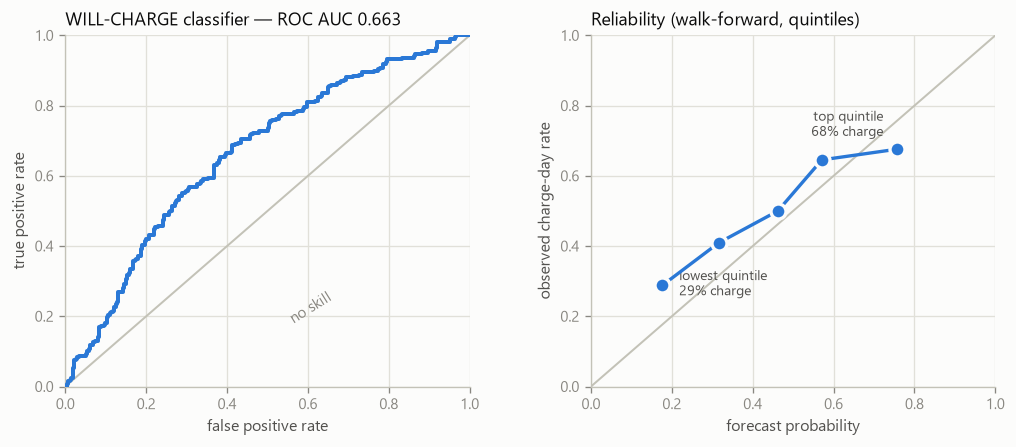

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), gridspec_kw=dict(wspace=0.3))

ax = axes[0]
fpr, tpr, _ = roc_curve(OOF_A.y, OOF_A.pred)
ax.plot([0, 1], [0, 1], color=AXIS, lw=1.2, zorder=2)
ax.plot(fpr, tpr, color=S1, lw=2.4, zorder=4)
clean(ax, grid="both")
ax.text(0.55, 0.18, "no skill", color=MUTED, fontsize=9, rotation=32)
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f"WILL-CHARGE classifier — ROC AUC {HEAD_A['roc_auc']:.3f}",
             loc="left", fontsize=10.5, color=INK)

ax = axes[1]
ax.plot([0, 1], [0, 1], color=AXIS, lw=1.2, zorder=2)
ax.plot(calibration.mean_forecast, calibration.observed_rate, "-o", color=S1, lw=2,
        ms=9, mec=SURF, mew=2, zorder=4)
clean(ax, grid="both")
ax.annotate(f"lowest quintile\n{100 * calibration.observed_rate.iloc[0]:.0f}% charge",
            xy=(calibration.mean_forecast.iloc[0], calibration.observed_rate.iloc[0]),
            xytext=(10, -6), textcoords="offset points", fontsize=8.5, color=INK2)
ax.annotate(f"top quintile\n{100 * calibration.observed_rate.iloc[-1]:.0f}% charge",
            xy=(calibration.mean_forecast.iloc[-1], calibration.observed_rate.iloc[-1]),
            xytext=(-8, 8), textcoords="offset points", fontsize=8.5, color=INK2, ha="right")
ax.set_xlabel("forecast probability"); ax.set_ylabel("observed charge-day rate")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Reliability (walk-forward, quintiles)", loc="left", fontsize=10.5, color=INK)

save_fig(fig, "f5_classifier.png")
plt.show()

## 10 · Head B — charging energy

### 10.1 Session energy, conditional on a session occurring

In [22]:
SESSION_FEATURES = ["uid", "hour", "dow", "month", "km_3d", "km_7d", "km_14d", "km_28d",
                    "km_since_charge", "days_since_charge", "soc_prev",
                    "user_rate", "kwh_7d", "kwh_28d", "kt_day"]

session_model = lambda: lgb.LGBMRegressor(
    n_estimators=400, learning_rate=0.04, num_leaves=15, min_child_samples=20,
    subsample=0.9, subsample_freq=1, colsample_bytree=0.8, reg_lambda=2.0,
    verbose=-1, random_state=0)

# no-model reference: median energy of the household's previous 5 sessions (known before the session starts)
SESSIONS = SESSIONS.sort_values(["id", "start_time"]).reset_index(drop=True)
SESSIONS["trailing5_energy"] = SESSIONS.groupby("id").ENERGY.transform(lambda s: s.shift().rolling(5, min_periods=1).median())

sess = SESSIONS.dropna(subset=SESSION_FEATURES + ["ENERGY"])
OOF_B = walk_forward(sess, SESSION_FEATURES, "ENERGY", session_model, "reg")
HEAD_B = score_regressor(OOF_B, "ENERGY")

# physics-only reference: energy consumed since the last charge
physics_pred = np.clip(OOF_B.km_since_charge * CONSUMPTION, 0, CAPACITY_KWH)
HEAD_B["mae_physics_baseline"] = round(mean_absolute_error(OOF_B.ENERGY, physics_pred), 2)
HEAD_B["mae_trailing_median5"] = round(mean_absolute_error(OOF_B.ENERGY, OOF_B.trailing5_energy.fillna(OOF_B.baseline)), 2)

for k, v in HEAD_B.items():
    print(f"  {k:24s} {v}")

  n                        432
  mae                      12.45
  rmse                     16.11
  mae_baseline             15.97
  mean_actual              25.41
  nmae_pct                 49.0
  skill_vs_baseline_pct    22.1
  mae_physics_baseline     20.79
  mae_trailing_median5     15.98


### 10.2 Energy volume over a horizon

Individual sessions are erratic. The quantity an EMS or a DSO actually schedules against is
energy over a window, and that aggregates in two independent directions: **time** (longer
horizon) and **portfolio** (more households).

Two references are scored on the same rows: the training-set median, and a **trailing 28-day
average** — the household's own energy over the previous 28 days, scaled to the horizon — which
needs no model.

> **Modelling note.** The forward-looking target is summed over the next *H* **observed** days.
> Because outage days are removed from the panel before this step, a horizon skips over masked
> periods rather than counting them as zero-energy days. Counting them as zeros would
> manufacture an artificial low-demand signal precisely where the data is absent.

In [23]:
HORIZONS = [1, 3, 7, 14]
vol = TRAIN.copy()
for H in HORIZONS:
    vol[f"kwh_fwd{H}"] = (vol.groupby("id").kwh
                          .transform(lambda s: s[::-1].rolling(H, min_periods=H).sum()[::-1]))

VOLUME_FEATURES = ["uid", "days_since_charge", "km_since_charge", "soc_prev", "user_rate",
                   "km_7d", "km_14d", "km_28d", "kwh_7d", "kwh_28d", "dow", "month"]

volume_model = lambda: lgb.LGBMRegressor(
    n_estimators=200, learning_rate=0.05, num_leaves=7, min_child_samples=40,
    reg_lambda=5.0, colsample_bytree=0.7, verbose=-1, random_state=0)

volume_rows, OOF_VOL = [], {}
for H in HORIZONS:
    target = f"kwh_fwd{H}"
    oof = walk_forward(vol.dropna(subset=[target]), VOLUME_FEATURES, target, volume_model, "reg")
    result = score_regressor(oof, target)

    # no-model reference: the household's own 28-day energy pace, scaled to the horizon
    oof["trailing28"] = oof.kwh_28d / 28.0 * H
    result["mae_trailing28"] = round(mean_absolute_error(oof[target], oof.trailing28), 2)
    result["nmae_trailing28_pct"] = round(100 * result["mae_trailing28"] / result["mean_actual"], 1)

    # the same forecast, aggregated across the four households per issue date
    fleet = oof.groupby("date").agg(actual=(target, "sum"), predicted=("pred", "sum"), trailing=("trailing28", "sum"))
    result["fleet_mae"] = round(mean_absolute_error(fleet.actual, fleet.predicted), 2)
    result["fleet_mean"] = round(fleet.actual.mean(), 2)
    result["fleet_nmae_pct"] = round(100 * result["fleet_mae"] / result["fleet_mean"], 1)
    result["fleet_mae_trailing28"] = round(mean_absolute_error(fleet.actual, fleet.trailing), 2)
    result["fleet_nmae_trailing28_pct"] = round(100 * result["fleet_mae_trailing28"] / result["fleet_mean"], 1)
    result["horizon_days"] = H
    volume_rows.append(result)
    OOF_VOL[H] = oof

volume = pd.DataFrame(volume_rows).set_index("horizon_days")
display(volume[["n", "mae", "mae_trailing28", "nmae_pct", "nmae_trailing28_pct", "skill_vs_baseline_pct",
                "fleet_nmae_pct", "fleet_nmae_trailing28_pct"]])

,n,mae,mae_trailing28,nmae_pct,nmae_trailing28_pct,skill_vs_baseline_pct,fleet_nmae_pct,fleet_nmae_trailing28_pct
horizon_days,,,,,,,,
1,552,15.95,16.11,103.4,104.5,-3.4,56.2,55.4
3,544,27.07,25.33,58.3,54.6,-0.6,32.7,30.1
7,528,45.76,36.87,42.2,34.0,8.8,24.8,18.2
14,500,72.01,58.25,33.2,26.9,21.6,19.8,14.7


### Figure 4 · nMAE against horizon and portfolio width

Solid: the model. Dashed: the trailing 28-day average, which needs no model.

saved outputs\figures\f4_horizon.png


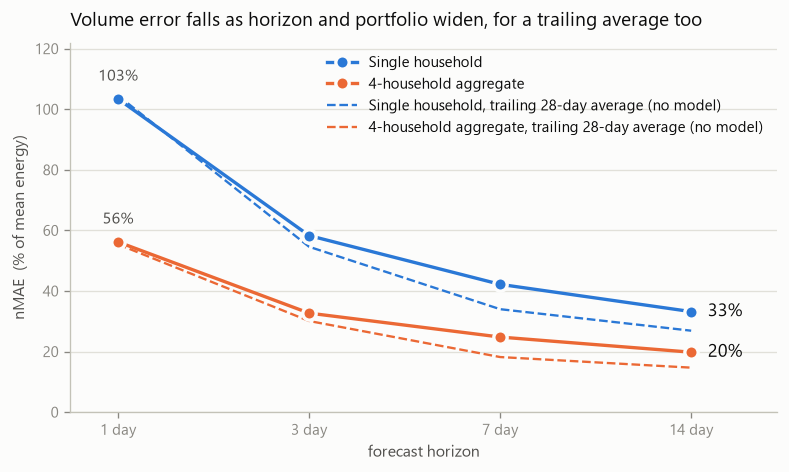

In [24]:
x = np.arange(len(HORIZONS))
per_household = volume.nmae_pct.values
fleet_level = volume.fleet_nmae_pct.values

fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.plot(x, per_household, "-o", color=S1, lw=2, ms=8, mec=SURF, mew=2,
        label="Single household", zorder=4)
ax.plot(x, fleet_level, "-o", color=S2, lw=2, ms=8, mec=SURF, mew=2,
        label="4-household aggregate", zorder=4)
ax.plot(x, volume.nmae_trailing28_pct.values, "--", color=S1, lw=1.4,
        label="Single household, trailing 28-day average (no model)", zorder=3)
ax.plot(x, volume.fleet_nmae_trailing28_pct.values, "--", color=S2, lw=1.4,
        label="4-household aggregate, trailing 28-day average (no model)", zorder=3)
clean(ax)
for series in (per_household, fleet_level):
    ax.annotate(f"{series[0]:.0f}%", xy=(x[0], series[0]), xytext=(0, 11),
                textcoords="offset points", fontsize=9.5, color=INK2, ha="center")
    ax.annotate(f"{series[-1]:.0f}%", xy=(x[-1], series[-1]), xytext=(10, 0),
                textcoords="offset points", fontsize=10.5, color=INK, va="center")
ax.set_xticks(x); ax.set_xticklabels([f"{h} day" for h in HORIZONS])
ax.set_xlabel("forecast horizon"); ax.set_ylabel("nMAE  (% of mean energy)")
ax.set_ylim(0, max(per_household) * 1.18); ax.set_xlim(-0.25, len(HORIZONS) - 0.55)
ax.legend(loc="upper right")
ax.set_title("Volume error falls as horizon and portfolio widen, for a trailing average too",
             loc="left", fontsize=11.5, color=INK, pad=10)

save_fig(fig, "f4_horizon.png")
plt.show()

## 11 · Head C — connection window

The window bounds every schedule the optimiser may propose, so it is predicted directly.

In [25]:
DWELL_FEATURES = ["uid", "hour", "dow", "month", "km_7d", "days_since_charge",
                  "soc_prev", "user_rate"]

dwell_model = lambda: lgb.LGBMRegressor(
    n_estimators=250, learning_rate=0.05, num_leaves=10, min_child_samples=15,
    verbose=-1, random_state=0)

# no-model reference: median plug-in window of the household's previous 5 sessions
SESSIONS["trailing5_dwell"] = SESSIONS.groupby("id").dwell_h.transform(lambda s: s.shift().rolling(5, min_periods=1).median())

dwell_data = SESSIONS.dropna(subset=DWELL_FEATURES + ["dwell_h"])
OOF_C = walk_forward(dwell_data, DWELL_FEATURES, "dwell_h", dwell_model, "reg")
HEAD_C = score_regressor(OOF_C, "dwell_h")
HEAD_C["mae_trailing_median5"] = round(mean_absolute_error(OOF_C.dwell_h, OOF_C.trailing5_dwell.fillna(OOF_C.baseline)), 2)

for k, v in HEAD_C.items():
    print(f"  {k:24s} {v}")

HEAD_C.update({
    "dwell_median_h": round(ALL_CHARGE.dwell_h.median(), 2),
    "active_median_h": round(ALL_CHARGE.charge_h.median(), 2),
    "slack_median_h": round(ALL_CHARGE.slack_h.median(), 2),
    "slack_gt2h_pct": round(100 * (ALL_CHARGE.slack_h > 2).mean()),
    "overnight_pct": round(100 * len(overnight) / len(ALL_CHARGE)),
    "overnight_energy_pct": round(100 * overnight.ENERGY.sum() / ALL_CHARGE.ENERGY.sum()),
})

  n                        432
  mae                      3.65
  rmse                     5.48
  mae_baseline             4.1
  mean_actual              8.59
  nmae_pct                 42.5
  skill_vs_baseline_pct    11.0
  mae_trailing_median5     4.2


## 12 · Physical closure — why volume is forecastable and timing is not

Over a long enough window, energy charged must equal energy driven. This is the constraint
that makes volume forecastable at all, and its absence at day level is exactly why Head A is hard.
It is also why a trailing average of recent energy captures most of that predictability (§10.2).

In [26]:
closure_rows = []
for hid in IDS:
    p = PANEL[(PANEL.id == hid) & (~PANEL.outage)]
    row = {"id": hid}
    for window in (7, 30):
        charged = p.kwh.rolling(window).sum()
        driven = p.km.rolling(window).sum() * CONSUMPTION
        row[f"corr_{window}d"] = round(charged.corr(driven), 2)
    row["charged_over_driven"] = round(p.kwh.sum() / (p.km.sum() * CONSUMPTION), 2)
    closure_rows.append(row)

closure = pd.DataFrame(closure_rows)
display(closure)
print(f"30-day correlation range: {closure.corr_30d.min():.2f} – {closure.corr_30d.max():.2f}")

,id,corr_7d,corr_30d,charged_over_driven
0,id01,0.63,0.86,0.99
1,id02,0.53,0.80,1.40
2,id03,0.56,0.78,0.93
3,id04,0.32,0.67,1.15


30-day correlation range: 0.67 – 0.86


The ratio above exceeds 1.0 for some households because charged energy includes charger and
battery losses, and because reconstructed distance excludes the sub-km trips filtered in §7.
The correlation, not the ratio, is the claim being made.

## 13 · Counterfactual — what the forecast is worth downstream

Each observed session is re-placed **inside its own observed connection window**, delivering
exactly the energy that was actually delivered, at the charger's rated 7.4 kW. No behaviour
changes: the user plugs in and unplugs at the same moments. This bounds the benefit by what
the recorded flexibility already permitted, rather than assuming users will respond to signals.

Two placements are compared against the uncontrolled baseline of charging on plug-in:
cost-optimal (cheapest slots in the window) and PV-optimal (highest-generation slots).

In [27]:
value_rows = []
for _, s in SESSIONS.iterrows():
    if pd.isna(s.ENERGY) or s.ENERGY <= 0:
        continue
    start = pd.Timestamp(s.start_time).floor("30min")
    end = pd.Timestamp(s.end_time).ceil("30min")
    stream = ENERGY[s.id].set_index("ts_naive").sort_index()
    window = stream.loc[start:end]
    if len(window) < 2:
        continue

    price = window.elec_price.ffill().fillna(0.095).to_numpy()
    pv = window.solar_kWh.fillna(0).to_numpy()
    n_slots = len(price)

    energy_needed = float(s.ENERGY)
    slot_capacity = CHARGER_KW * SLOT_H                       # 3.7 kWh per 30-min slot
    slots_required = min(int(np.ceil(energy_needed / slot_capacity)), n_slots)
    per_slot = energy_needed / slots_required

    uncontrolled = np.zeros(n_slots); uncontrolled[:slots_required] = per_slot
    cost_optimal = np.zeros(n_slots); cost_optimal[np.argsort(price)[:slots_required]] = per_slot
    pv_optimal = np.zeros(n_slots);   pv_optimal[np.argsort(-pv)[:slots_required]] = per_slot

    value_rows.append({
        "id": s.id, "start": s.start_time, "kwh": energy_needed,
        "cost_uncontrolled": float((uncontrolled * price).sum()),
        "cost_optimal": float((cost_optimal * price).sum()),
        "pv_uncontrolled": float(np.minimum(uncontrolled, pv).sum()),
        "pv_optimal": float(np.minimum(pv_optimal, pv).sum()),
        "spare_slots": n_slots - slots_required,
    })

VALUE = pd.DataFrame(value_rows)
saving = VALUE.cost_uncontrolled.sum() - VALUE.cost_optimal.sum()

RESULT_VALUE = {
    "sessions": len(VALUE),
    "energy_kwh": round(VALUE.kwh.sum()),
    "cost_uncontrolled_eur": round(VALUE.cost_uncontrolled.sum(), 2),
    "cost_optimal_eur": round(VALUE.cost_optimal.sum(), 2),
    "saving_eur": round(saving, 2),
    "saving_pct": round(100 * saving / VALUE.cost_uncontrolled.sum(), 1),
    "saving_per_household_year_eur": round(saving / len(IDS), 2),
    "pv_uncontrolled_pct": round(100 * VALUE.pv_uncontrolled.sum() / VALUE.kwh.sum(), 1),
    "pv_optimal_pct": round(100 * VALUE.pv_optimal.sum() / VALUE.kwh.sum(), 1),
    "sessions_with_slack_pct": round(100 * (VALUE.spare_slots > 0).mean()),
    "median_spare_hours": round(VALUE.spare_slots.median() * SLOT_H, 1),
}
for k, v in RESULT_VALUE.items():
    print(f"  {k:32s} {v}")

  sessions                         734
  energy_kwh                       19626
  cost_uncontrolled_eur            1252.35
  cost_optimal_eur                 785.51
  saving_eur                       466.83
  saving_pct                       37.3
  saving_per_household_year_eur    116.71
  pv_uncontrolled_pct              0.7
  pv_optimal_pct                   1.7
  sessions_with_slack_pct          100
  median_spare_hours               5.0


**The PV number is the honest caveat.** Optimal placement lifts direct PV-to-EV overlap only
from ~0.7% to ~1.7% of charged energy. A 2.1 kWp array simply cannot feed a 7.4 kW charger
in an Irish winter, and most charging is overnight anyway. Tariff arbitrage is where the value
is at household level; PV alignment becomes material only once the stationary battery and
community sharing of Service 5 enter the loop. Reporting the PV figure as a "2.6× uplift"
would be technically true and substantively misleading.

### Figure 6 · Tariff cost, uncontrolled vs. window-optimal

saved outputs\figures\f6_value.png


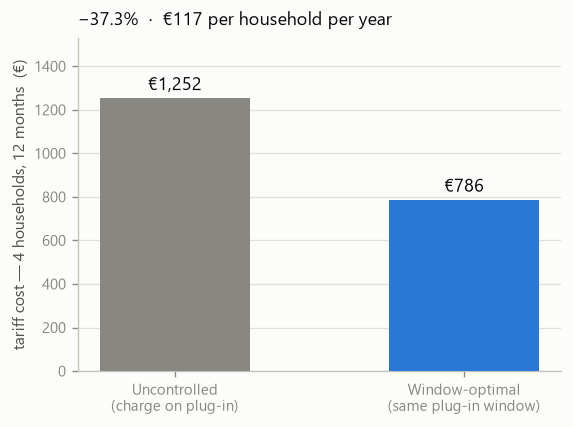

In [28]:
fig, ax = plt.subplots(figsize=(5.2, 3.6))
values = [RESULT_VALUE["cost_uncontrolled_eur"], RESULT_VALUE["cost_optimal_eur"]]
bars = ax.bar(["Uncontrolled\n(charge on plug-in)", "Window-optimal\n(same plug-in window)"],
              values, color=[MUTED, S1], width=0.52, zorder=3)
clean(ax)
for bar, value in zip(bars, values):
    ax.annotate(f"€{value:,.0f}", xy=(bar.get_x() + bar.get_width() / 2, value),
                xytext=(0, 5), textcoords="offset points", ha="center",
                fontsize=11, color=INK)
ax.set_ylabel("tariff cost — 4 households, 12 months  (€)")
ax.set_ylim(0, max(values) * 1.22)
ax.set_title(f"−{RESULT_VALUE['saving_pct']}%  ·  "
             f"€{RESULT_VALUE['saving_per_household_year_eur']:.0f} per household per year",
             loc="left", fontsize=10.5, color=INK, pad=8)

save_fig(fig, "f6_value.png")
plt.show()

## 14 · Results summary

Every figure quoted in the Service 4 deck, regenerated from this notebook's run.

In [29]:
summary = {
    "dataset": {
        "households": len(IDS),
        "charging_sessions": int(len(ALL_CHARGE)),
        "journeys": int(len(ALL_JOURNEY)),
        "energy_delivered_kwh": int(ALL_CHARGE.ENERGY.sum()),
        "distance_km": int(ALL_JOURNEY.Distance.sum()),
        "household_days": int(len(PANEL)),
        "outage_days_masked": int(PANEL.outage.sum()),
        "usable_household_days": int(len(TRAIN)),
        "sub_km_journey_pct": round(100 * (ALL_JOURNEY.Distance < MIN_TRIP_KM).mean()),
    },
    "head_a_will_charge": {**HEAD_A, "configuration": f"{BEST_KEY[0]} / {BEST_KEY[1]}",
                           "lowest_quintile_rate_pct": round(100 * calibration.observed_rate.iloc[0]),
                           "top_quintile_rate_pct": round(100 * calibration.observed_rate.iloc[-1])},
    "head_b_session_energy": HEAD_B,
    "head_b_volume_nmae_pct": {f"{h}d": volume.loc[h, "nmae_pct"] for h in HORIZONS},
    "head_b_volume_fleet_nmae_pct": {f"{h}d": volume.loc[h, "fleet_nmae_pct"] for h in HORIZONS},
    "head_b_volume_trailing28_nmae_pct": {f"{h}d": volume.loc[h, "nmae_trailing28_pct"] for h in HORIZONS},
    "head_b_volume_fleet_trailing28_nmae_pct": {f"{h}d": volume.loc[h, "fleet_nmae_trailing28_pct"] for h in HORIZONS},
    "head_c_connection_window": HEAD_C,
    "physical_closure_corr_30d": dict(zip(closure.id, closure.corr_30d)),
    "counterfactual_value": RESULT_VALUE,
    "behaviour": {
        "evening_start_pct": round(evening_share),
        "pv_window_start_pct": round(pv_window_share),
        "tariff_night_eur": round(price_by_hour.loc[0:6].mean(), 3),
        "tariff_day_eur": round(price_by_hour.loc[8:23].mean(), 3),
    },
}

(OUT_DIR / "service4_results.json").write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")

# Exports consumed by the branded-deck figure layer, so both renderings of every
# chart come from this notebook's run rather than from a parallel code path.
pd.DataFrame({
    "hour": range(24),
    "charging_starts": hour_charge.values,
    "journey_starts": hour_journey.values,
    "pv_mean_kwh": pv_by_hour.values,
    "price_mean_eur": price_by_hour.values,
}).to_csv(OUT_DIR / "hour_histograms.csv", index=False)

OOF_A[["id", "date", "y", "pred"]].to_csv(OUT_DIR / "oof_classifier.csv", index=False)
calibration.to_csv(OUT_DIR / "calibration.csv")
volume.to_csv(OUT_DIR / "volume_by_horizon.csv")
profiles.to_csv(OUT_DIR / "profiles.csv", index=False)
print(f"artefacts written to {OUT_DIR.as_posix()}/\n")

print(json.dumps(summary, indent=2, default=str))

artefacts written to outputs/

{
  "dataset": {
    "households": 4,
    "charging_sessions": 738,
    "journeys": 18603,
    "energy_delivered_kwh": 19626,
    "distance_km": 92983,
    "household_days": 1459,
    "outage_days_masked": 139,
    "usable_household_days": 1208,
    "sub_km_journey_pct": 53
  },
  "head_a_will_charge": {
    "n": 552,
    "positive_rate": 50.4,
    "roc_auc": 0.663,
    "pr_auc": 0.631,
    "pr_auc_base": 0.504,
    "brier": 0.239,
    "brier_skill": 0.127,
    "f1": 0.629,
    "accuracy": 0.627,
    "persistence_auc": 0.524,
    "recency_only_auc": 0.497,
    "household_rate_only_auc": 0.628,
    "household_rate_only_within_household_auc": 0.448,
    "within_household_auc": 0.616,
    "lowest_quintile_share_of_one_household_pct": 89,
    "within_household_lowest_quintile_pct": 37,
    "within_household_top_quintile_pct": 61,
    "configuration": "compact-8 / logreg",
    "lowest_quintile_rate_pct": 29,
    "top_quintile_rate_pct": 68
  },
  "head_b_sessi

### How to read these results

**Timing (Head A) is weak but real and calibrated.** Pooled ROC-AUC 0.66 is weak-to-moderate
discrimination, and this notebook does not dress it up: day-level timing in a four-household panel
sits close to its noise floor. The pooled figure also flatters, because the households differ in
how often they charge — a household's own base rate alone gives 0.63. Within a household the model
reaches 0.62 against 0.45–0.47 for persistence, recency and the base rate: a real need-to-charge
signal, but a modest one. The pooled quintile spread (lowest 29 %, top 68 %) is mostly a household
ranking; formed within each household it is 37 % against 61 %. The model-selection sweep in §9
shows an 8-feature logistic regression beating a 17-feature gradient-boosted model, which
identifies data volume — not model capacity — as the binding constraint.

**Volume (Head B) is predictable by aggregation, not by the model.** nMAE falls from ~103 % at one
day to ~33 % at fourteen days per household, and to ~20 % pooled across four. A trailing 28-day
average falls just as far (~105 % to ~27 % per household, ~55 % to ~15 % pooled) and is as good or
better beyond one day, so the fall reflects aggregation — Section 12 gives the reason, the physics
closes — not skill of the model. Session energy (§10.1) is where the model adds skill: MAE
12.5 kWh against 16.0 for the training median and for the household's trailing median (22 % lower).

**The window (Head C) is wide, and modestly predictable.** With median dwell of 9.4 h against
3.7 h of active charging, the scheduler does not need to know the minute a session starts. The
model's MAE (3.65 h) is 11 % lower than predicting the training median (4.10 h) and 13 % lower
than the household's trailing median (4.20 h): useful, not decisive. The service still needs the
window, the energy, and a calibrated probability — the three-head output contract. Against
no-model references, session energy wins clearly (22 % lower MAE), the will-charge ranking
modestly (within-household AUC 0.62 against at most 0.47), the window slightly (11 %), and the
volume forecast not at all.

### Reproducibility

- All model seeds fixed (`random_state=0`); `LogisticRegression` under `lbfgs` is deterministic.
- No forward-looking feature enters any training matrix; §8 enforces the temporal split.
- Artefacts written to `outputs/`, figures to `outputs/figures/` (both git-ignored).
- The reference environment is pinned in `requirements.txt` (Python 3.11 · numpy 1.26.4 · pandas 2.2.3
  · scikit-learn 1.5.2 · lightgbm 4.5.0 · xgboost 2.1.3); every number above was produced in it. Other
  versions can drift in the third decimal.